In [1]:
# Import libraries
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score,f1_score,roc_auc_score,confusion_matrix

from sklearn.cluster import KMeans

from mlxtend.frequent_patterns import apriori,association_rules

import joblib

In [2]:
# Load datasets
orders = pd.read_csv("datasets/orders.csv")

order_products_prior = pd.read_csv("datasets/order_products_prior.csv")

order_products_train = pd.read_csv("datasets/order_products_train.csv")

products = pd.read_csv("datasets/products.csv")

aisles = pd.read_csv("datasets/aisles.csv")

departments = pd.read_csv("datasets/departments.csv")

In [3]:
# Merge datasets for analysis
order_details = order_products_prior.merge(products,on="product_id")

order_details = order_details.merge(aisles,on="aisle_id")

order_details = order_details.merge(departments,on="department_id")

order_details = order_details.merge(orders,on="order_id")

## EDA

Text(0.5, 1.0, 'Orders by Day of Week')

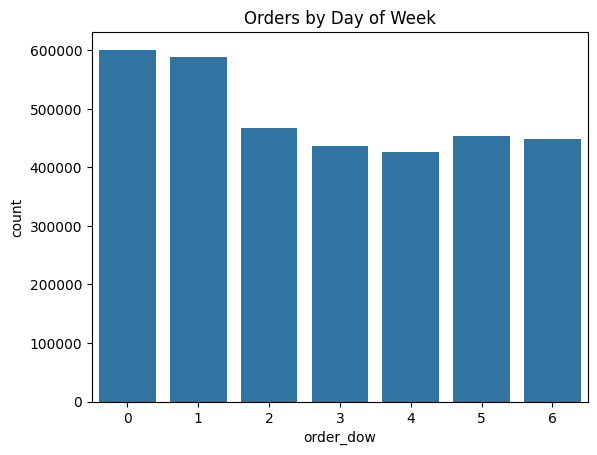

In [4]:
plt.figure()

sns.countplot(x="order_dow",data=orders)

plt.title("Orders by Day of Week")

Most grocery orders occur on weekends.

Text(0.5, 1.0, 'Orders by Hour')

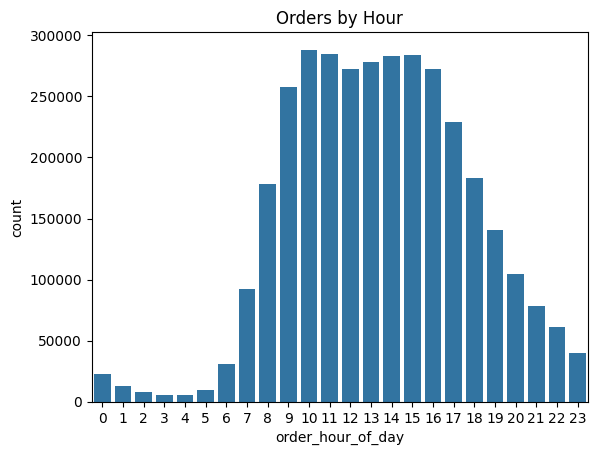

In [5]:
plt.figure()

sns.countplot(x="order_hour_of_day",data=orders)

plt.title("Orders by Hour")

Peak grocery orders occur in afternoon hours.

Text(0.5, 1.0, 'Top Departments')

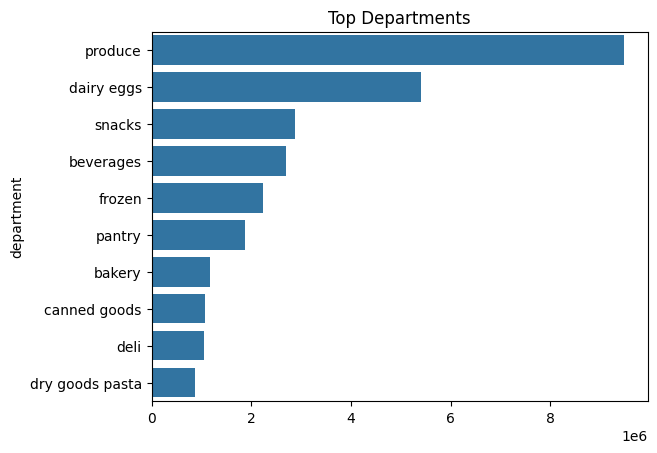

In [6]:
top_dept = order_details["department"].value_counts().head(10)

plt.figure()

sns.barplot(x=top_dept.values,y=top_dept.index)

plt.title("Top Departments")

Produce and Dairy dominate Instacart purchases.

Text(0.5, 1.0, 'Top Aisles')

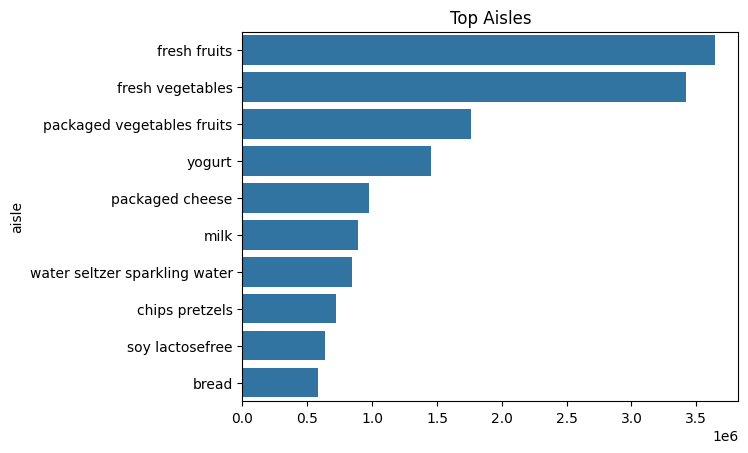

In [7]:
top_aisles = order_details["aisle"].value_counts().head(10)

plt.figure()

sns.barplot(x=top_aisles.values,y=top_aisles.index)

plt.title("Top Aisles")

Text(0.5, 1.0, 'Reorder Distribution')

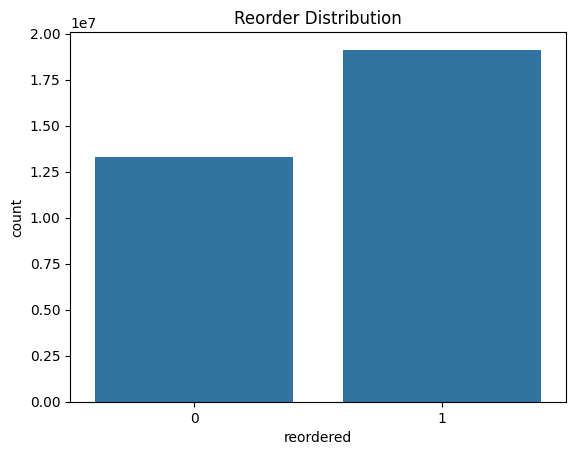

In [8]:
sns.countplot(x="reordered",data=order_products_prior)

plt.title("Reorder Distribution")

Many grocery items are reordered frequently.

## OBJECTIVE 1
### Product Reorder Prediction

In [9]:
# --- Take a manageable sample to avoid memory issues ---
sample_orders = orders.sample(50000, random_state=42)
order_details = order_products_prior[
    order_products_prior["order_id"].isin(sample_orders["order_id"])
].merge(sample_orders, on="order_id")
order_details = order_details.merge(products, on="product_id")\
                             .merge(aisles, on="aisle_id")\
                             .merge(departments, on="department_id")

In [10]:
# 1. User-level features
user_features = order_details.groupby("user_id").agg(
    total_orders=("order_number","max"),
    avg_days_between_orders=("days_since_prior_order","mean")
).fillna(0).reset_index()

In [11]:
# 2. Product-level features
product_features = order_details.groupby("product_id").agg(
    product_popularity=("order_id","count"),
    product_reorder_rate=("reordered","mean")
).reset_index()

In [12]:
# 3. User-product interaction
user_product_features = order_details.groupby(["user_id","product_id"]).agg(
    purchase_count=("order_id","count")
).reset_index()

In [13]:
# Merge features together
ml_data = user_product_features.merge(user_features, on="user_id")
ml_data = ml_data.merge(product_features, on="product_id")

In [14]:
# Check missing values
ml_data.isna().sum()

user_id                    0
product_id                 0
purchase_count             0
total_orders               0
avg_days_between_orders    0
product_popularity         0
product_reorder_rate       0
dtype: int64

In [15]:
# Add target column
ml_data["target"] = order_details.groupby(["user_id","product_id"])["reordered"].max().values


In [16]:
# --- Prepare X and y ---
feature_cols = [
    "total_orders",
    "avg_days_between_orders",
    "product_popularity",
    "product_reorder_rate",
    "purchase_count"
]
X = ml_data[feature_cols]
y = ml_data["target"]

In [17]:
# --- Train-test split ---
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


In [18]:
# --- Scale features for Logistic Regression ---
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## MODEL 1
### Logistic Regression
### Hyperparameter Tuning

In [19]:
# --- Model 1: Logistic Regression ---
param_grid = {"C":[0.01, 0.1, 1, 10]}
log_model = LogisticRegression(max_iter=500)
grid_log = GridSearchCV(log_model, param_grid, cv=3, scoring="f1")
grid_log.fit(X_train_scaled, y_train)
best_log = grid_log.best_estimator_

## MODEL 2
### Random Forest

In [20]:
# --- Model 2: Random Forest ---
rf = RandomForestClassifier(random_state=42)
param_grid_rf = {"n_estimators":[100,200], "max_depth":[5,10]}
grid_rf = GridSearchCV(rf, param_grid_rf, cv=3, scoring="f1")
grid_rf.fit(X_train, y_train)
best_rf = grid_rf.best_estimator_

### Model Evaluation
### Logistic Regression

In [21]:
# Logistic Regression
log_pred = best_log.predict(X_test_scaled)
print("Logistic Regression Metrics")
print("Accuracy:", accuracy_score(y_test, log_pred))
print("F1 Score:", f1_score(y_test, log_pred))
print("ROC AUC:", roc_auc_score(y_test, log_pred))

Logistic Regression Metrics
Accuracy: 0.7114589291213868
F1 Score: 0.7648424543946932
ROC AUC: 0.692889322699236


In [22]:
# Random Forest
rf_pred = best_rf.predict(X_test)
print("\nRandom Forest Metrics")
print("Accuracy:", accuracy_score(y_test, rf_pred))
print("F1 Score:", f1_score(y_test, rf_pred))
print("ROC AUC:", roc_auc_score(y_test, rf_pred))


Random Forest Metrics
Accuracy: 0.7434334990540719
F1 Score: 0.7956977945942159
ROC AUC: 0.7210169452671217


In [23]:
# Save models and scaler
joblib.dump(best_rf, "rf_model.pkl")
joblib.dump(best_log, "log_model.pkl")
joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']

Text(0.5, 1.0, 'Confusion Matrix')

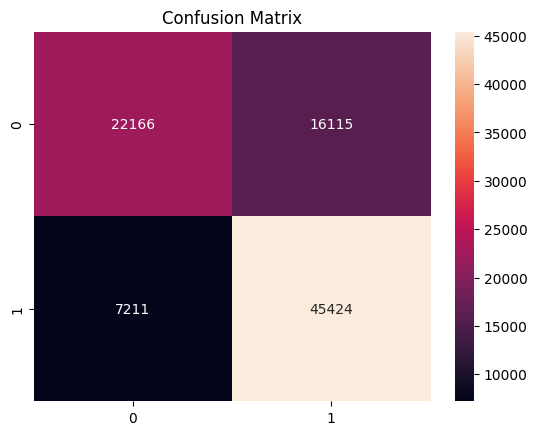

In [24]:
cm = confusion_matrix(y_test,rf_pred)

sns.heatmap(cm,annot=True,fmt="d")

plt.title("Confusion Matrix")

## OBJECTIVE 2
### Customer Segmentation

In [25]:
# Customer clustering
kmeans = KMeans(n_clusters=4,random_state=42).fit(user_features)
user_features['cluster'] = kmeans.labels_
user_features.to_csv("user_clusters.csv",index=False)

## OBJECTIVE 3
### Market Basket Analysis

In [26]:
from mlxtend.frequent_patterns import apriori, association_rules

basket = order_details.groupby(['order_id','product_name'])['reordered'].sum().unstack().fillna(0)
basket = basket.applymap(lambda x: 1 if x>0 else 0)

frequent_items = apriori(basket, min_support=0.01, use_colnames=True)
rules = association_rules(frequent_items, metric='lift', min_threshold=1)

rules.to_csv("basket_analysis.csv", index=False)
print(rules.head())

C:\Users\Thiwanka\AppData\Local\Temp\ipykernel_5844\3934549899.py:4: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  basket = basket.applymap(lambda x: 1 if x>0 else 0)
C:\Users\Thiwanka\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\mlxtend\frequent_patterns\fpcommon.py:175: DeprecationWarning: DataFrames with non-bool types result in worse computationalperformance and their support might be discontinued in the future.Please use a DataFrame with bool type
  warnings.warn(


                antecedents               consequents  antecedent support  \
0    (Organic Baby Spinach)  (Bag of Organic Bananas)            0.057475   
1  (Bag of Organic Bananas)    (Organic Baby Spinach)            0.097018   
2    (Organic Hass Avocado)  (Bag of Organic Bananas)            0.053220   
3  (Bag of Organic Bananas)    (Organic Hass Avocado)            0.097018   
4     (Organic Raspberries)  (Bag of Organic Bananas)            0.033545   

   consequent support   support  confidence      lift  representativity  \
0            0.097018  0.011380    0.198001  2.040878               1.0   
1            0.057475  0.011380    0.117299  2.040878               1.0   
2            0.097018  0.015209    0.285771  2.945557               1.0   
3            0.053220  0.015209    0.156764  2.945557               1.0   
4            0.097018  0.010083    0.300571  3.098099               1.0   

   leverage  conviction  zhangs_metric   jaccard  certainty  kulczynski  
0  0.005804 